In [2]:
import pandas as pd

df=pd.read_csv("Salary_Data.csv")

df


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


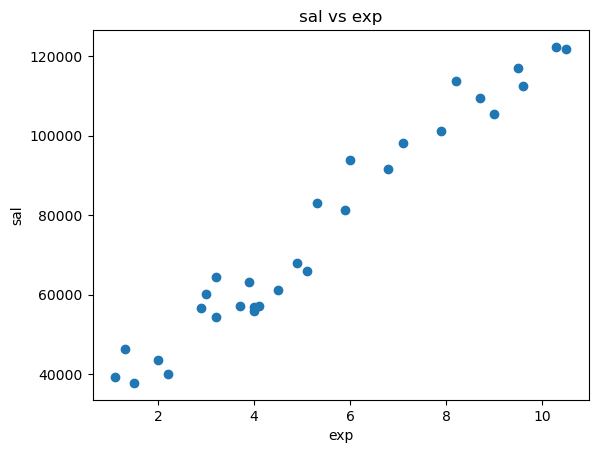

In [4]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df["YearsExperience"],df["Salary"]);

x=df["YearsExperience"]

In [5]:
X=df[["YearsExperience"]]

y=df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


X_train.shape, X_test.shape, y_train.shape, y_test.shape


((22, 1), (8, 1), (22,), (8,))

In [6]:
model=LinearRegression()
model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
model.coef_

array([9379.71049195])

In [8]:
model.intercept_

np.float64(26986.691316737248)

In [9]:
from sklearn.metrics import accuracy_score

In [10]:
f1=pd.DataFrame({"Actual":y_test,"predicted":model.predict(X_test)})

In [11]:
f1

,Actual,predicted
2,37731.0,41056.257055
28,122391.0,123597.709384
13,57081.0,65443.504334
10,63218.0,63567.562235
26,116969.0,116093.940990
24,109431.0,108590.172597
27,112635.0,117031.912039
11,55794.0,64505.533285


In [12]:
# plot the best fit line on the previous scatter chart

In [13]:
y_pred=model.predict(X_test)

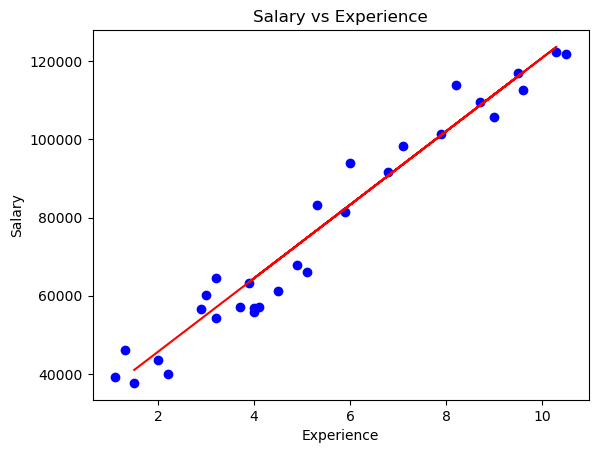

In [14]:
plt.scatter(df["YearsExperience"], df["Salary"], color="blue")
plt.plot(X_test, y_pred, color="red")
plt.title("Salary vs Experience")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error

In [16]:
mean_absolute_error(y_test,y_pred)

3508.5455930660555

In [17]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9779208335417602

### polynomial reg

In [22]:
x

0      1.1
1      1.3
2      1.5
3      2.0
4      2.2
5      2.9
6      3.0
7      3.2
8      3.2
9      3.7
10     3.9
11     4.0
12     4.0
13     4.1
14     4.5
15     4.9
16     5.1
17     5.3
18     5.9
19     6.0
20     6.8
21     7.1
22     7.9
23     8.2
24     8.7
25     9.0
26     9.5
27     9.6
28    10.3
29    10.5
Name: YearsExperience, dtype: float64

In [23]:
y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [24]:
#check  for overfit

In [28]:
# create polynomial features


In [33]:
from sklearn.preprocessing import PolynomialFeatures



In [34]:
poly = PolynomialFeatures(degree= 4)


In [36]:
x_poly = poly.fit_transform(X)


In [37]:
x_poly
# cross val, linear reg model, r2 score


array([[1.00000000e+00, 1.10000000e+00, 1.21000000e+00, 1.33100000e+00,
        1.46410000e+00],
       [1.00000000e+00, 1.30000000e+00, 1.69000000e+00, 2.19700000e+00,
        2.85610000e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01],
       [1.00000000e+00, 2.20000000e+00, 4.84000000e+00, 1.06480000e+01,
        2.34256000e+01],
       [1.00000000e+00, 2.90000000e+00, 8.41000000e+00, 2.43890000e+01,
        7.07281000e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01,
        8.10000000e+01],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02],
       [1.00000000e+00, 3.70000000e+00, 1.36900000e+01, 5.06530000e+01,
        1.87416100e+02],
       [1.00000000e+00, 3.9000

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x_poly, y,
random_state=0)

In [39]:
lr = LinearRegression()
lr.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
y_pred = lr.predict(x_test)


In [42]:
r2_score(y_test, y_pred)


0.9820816859990579

In [43]:
print("train",model.score(X_train,y_train))
print("test",model.score(X_test,y_test))


train 0.9395413526983522
test 0.9779208335417602
